In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/jgh-msss-topic-eng-only/sqllab_query_publicmsss_final_mtv_06172025_024124_20251112T192644.csv
/kaggle/input/jgh-msss-eng-topicstudy/sqllab_query_publicmsss_final_mtv_06172025_024124_20251112T192644.csv


In [2]:
!pip install spark-nlp pyspark nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 744.4/744.4 kB 15.8 MB/s eta 0:00:00


In [3]:
!pip install stylecloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.1/262.1 kB 7.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.4/161.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 16.3 MB/s eta 0:00:00
  Created wheel for stylecloud: filename=stylecloud-0.5.2-py3-none-any.whl size=259492 sha256=59d1be8eed6ab468c975ac2195c673e7df9d96ea47ace9d188a28265fb6ac562
  Stored in directory: /root/.cache/pip/wheels/25/62/2d/cbce408faa397b47b726645863be3e26b70de6c4d9b720c522
  Created wheel for tinycss: filename=tinycss-0.4-cp311-cp311-linux_x86_64.whl size=328284 sha256=5aee247b23808e04127c6e635d9c193ad3177d21586b7397bc0c9864cf68274c
  Stored in directory: /root/.cache/pip/wheels/57/c0/0f/7ed6f1bfca35d165d4979934ee25cf1

In [4]:
# Importing the neccessary libraries
import json
import os

import re
import random

import numpy as np
import pandas as pd

from wordcloud import (
    WordCloud,
    ImageColorGenerator,
    STOPWORDS)

import stylecloud

# Libraries and options for graphs
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
sns.set_style("darkgrid")

colors = sns.color_palette('PuBuGn')

# Options to display pandas dataframes
pd.options.display.max_colwidth = None
pd.options.display.float_format = '${:,.3f}'.format

In [5]:
import nltk
#nltk.download('stopwords')
from nltk.tokenize import RegexpTokenizer, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer 
from string import punctuation

# Importing Spark libraries and modules

import sparknlp
#import sparknlp_jsl

# Import Spark NLP
import sparknlp
from sparknlp.base import *
from sparknlp.annotator import *
from sparknlp.pretrained import PretrainedPipeline

#from sparknlp_jsl.annotator import *

# Module to display ner results 
# from sparknlp_display import NerVisualizer
# visualiser = NerVisualizer()

from pyspark.sql import SparkSession, Row
from pyspark.sql.types import StructType, StructField, StringType, ArrayType, IntegerType, FloatType, DoubleType, LongType
from pyspark.sql import types as T
from pyspark.sql import functions as F
from pyspark.sql.functions import udf, col, size, regexp_replace, trim, lower, lit, desc, row_number, monotonically_increasing_id, concat_ws, collect_list, concat, explode
from pyspark.sql.window import Window 

from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.clustering import LDA
from pyspark.ml.linalg import Vectors, SparseVector, DenseVector
from pyspark.ml.feature import Tokenizer, StopWordsRemover, RegexTokenizer, CountVectorizer, IDF

import warnings

In [6]:
# Settings and parameters for the Spark session
# As included in JSL notebooks

warnings.filterwarnings('ignore')

params = {"spark.driver.memory":"16G", 
          "spark.kryoserializer.buffer.max":"2000M", 
          "spark.driver.maxResultSize":"2000M"} 

print("Spark NLP Version :", sparknlp.version())
#print("Spark NLP_JSL Version :", sparknlp_jsl.version())

# Staring Healthcare Spark NLP session
# spark = sparknlp_jsl.start(license_keys['SECRET'], params=params)
#spark = sparknlp_jsl.start(params=params)
spark = sparknlp.start(params=params)
spark

Spark NLP Version : 6.2.2
:: loading settings :: url = jar:file:/usr/local/lib/python3.11/dist-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
com.johnsnowlabs.nlp#spark-nlp_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-8731765f-8bc9-4829-8005-5b48a1d8ecf4;1.0
	confs: [default]
	found com.johnsnowlabs.nlp#spark-nlp_2.12;6.2.2 in central
	found com.typesafe#config;1.4.2 in central
	found org.rocksdb#rocksdbjni;6.29.5 in central
	found com.amazonaws#aws-java-sdk-s3;1.12.500 in central
	found com.amazonaws#aws-java-sdk-kms;1.12.500 in central
	found com.amazonaws#aws-java-sdk-core;1.12.500 in central
	found commons-logging#commons-logging;1.1.3 in central
	found commons-codec#commons-codec;1.15 in central
	found org.apache.httpcomponents#httpclient;4.5.13 in central
	found org.apache.httpcomponents#httpcore;4.4.13 in central
	found software.amazon.ion#ion-java;1.0.2 in central
	found joda-time#joda-time;2.8.1 in central
	found com.amazonaws#jmespath-java;1.12.500 in central
	found com.g

# Data Import

In [7]:
! wget -N https://s3.amazonaws.com/auxdata.johnsnowlabs.com/public/resources/en/lemma-corpus-small/lemmas_small.txt -P /tmp

--2025-11-19 00:45:31--  https://s3.amazonaws.com/auxdata.johnsnowlabs.com/public/resources/en/lemma-corpus-small/lemmas_small.txt
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.218.224, 52.217.161.168, 54.231.233.64, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.218.224|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 189437 (185K) [text/plain]
Saving to: ‘/tmp/lemmas_small.txt’

lemmas_small.txt    100%[===================>] 185.00K  1005KB/s    in 0.2s    

2025-11-19 00:45:31 (1005 KB/s) - ‘/tmp/lemmas_small.txt’ saved [189437/189437]



In [8]:
! wget -N https://s3.amazonaws.com/auxdata.johnsnowlabs.com/public/resources/en/sentiment-corpus/default-sentiment-dict.txt -P /tmp

--2025-11-19 00:45:31--  https://s3.amazonaws.com/auxdata.johnsnowlabs.com/public/resources/en/sentiment-corpus/default-sentiment-dict.txt
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.217.70.246, 54.231.171.240, 52.217.92.230, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.217.70.246|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 289 [text/plain]
Saving to: ‘/tmp/default-sentiment-dict.txt’

default-sentiment-d 100%[===================>]     289  --.-KB/s    in 0s      

2025-11-19 00:45:32 (3.68 MB/s) - ‘/tmp/default-sentiment-dict.txt’ saved [289/289]



Here we start our topic modelling. First, we access the data and read it into Spark dataframe.

In [9]:
# File location and type
file_location = "/kaggle/input/jgh-msss-eng-topicstudy/sqllab_query_publicmsss_final_mtv_06172025_024124_20251112T192644.csv"
file_type = "csv"

In [10]:
# CSV options
infer_schema = True
first_row_is_header = True
delimiter = ","

In [11]:
df = spark.read \
.option("header", first_row_is_header) \
.csv(file_location)

In [12]:
df = df.withColumn("id", monotonically_increasing_id())

In [13]:
df.show(10, truncate=10)

25/11/19 00:45:39 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+------+-----+-------+----+------+--------------+---------------+----------+--------+----------+----------+-----------+----------+----------+------------+-----------+----------+-----------+---------------+-------------------+-------------+-------------+-------------+----------+----------+---+
|annual|month|quarter|week|yyyyqq|answerssheetid|participationid| patientid|language| createdat| updatedat|completedat|  timezone|questionid|questiontype|answervalue|answertype|projectname|projecttimezone|questionnaireidname|questiontitle|secteur_label|secteur_value|inst_label|   dat_res| id|
+------+-----+-------+----+------+--------------+---------------+----------+--------+----------+----------+-----------+----------+----------+------------+-----------+----------+-----------+---------------+-------------------+-------------+-------------+-------------+----------+----------+---+
|  2024|   10|      4|  43|2024Q4|    d303-00...|     d303-00...|d303-00...|      en|2024-10...|2024-10...| 2024-10...

Let's checkout what kind of information is stored in our data.

In [14]:
print(df.columns)

['annual', 'month', 'quarter', 'week', 'yyyyqq', 'answerssheetid', 'participationid', 'patientid', 'language', 'createdat', 'updatedat', 'completedat', 'timezone', 'questionid', 'questiontype', 'answervalue', 'answertype', 'projectname', 'projecttimezone', 'questionnaireidname', 'questiontitle', 'secteur_label', 'secteur_value', 'inst_label', 'dat_res', 'id']


For topic modelling, we need only textual data, thus, we create a new dataframe only with the column of interest.

In [15]:
import_c = True
text_col = 'answervalue'
print(f"\t\t\t---- Starting the pipeline built for >>> {text_col} <<< with import condition {import_c} ----")

			---- Starting the pipeline built for >>> answervalue <<< with import condition True ----


In [16]:
df = df.withColumn("id", df["id"].cast(IntegerType()))
non_null_index = (df.filter(df[text_col].isNotNull())).select('id')

In [17]:
df_clean = df.select(text_col).filter(F.col(text_col).isNotNull())
print(f"\n\t1. Cleaning the input for {df.count()} in toal. Null vs. Non-Null = {non_null_index.count()} : {df.count()-non_null_index.count()}. Null = {(df.count()-non_null_index.count()) * 100. / df.count():.2f}%")
print('\t---'*20)


	1. Cleaning the input for 2798 in toal. Null vs. Non-Null = 2460 : 338. Null = 12.08%
	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---


The data that we will use further for the analysis looks as follows:

In [18]:
df_clean.show(50, truncate=150)

+------------------------------------------------------------------------------------------------------------------------------------------------------+
|                                                                                                                                           answervalue|
+------------------------------------------------------------------------------------------------------------------------------------------------------+
|                                                      I was feeling pain and I appreciated getting CT scan and blood test before giving prescription. |
|                                                                                                                                       Professionally |
|                                 MY ONCOLOGIST SENT ME TO THE ER - I WAS TRIAGED & PUT ON A GURNEY + SENT TO A ROOM CUZ MY BREATHING WAS VERY LABOURED|
|Outstanding, compassionate and personal care. Every staff member I interacted wit

# Data Cleaning

In [19]:
# Cleaning

@udf
def lower_clean_str(s):
    my_punctuation = '!''\"#$%&\'()*+,-./:;<=>?[\\]^_`{|}~•@â'
    #punc = "!''\"#$&\'()*+,-./:;<=>?@[\\]^_`{|}~"
    lowercased_str = s.lower()
    for c in my_punctuation:
        lowercased_str = lowercased_str.replace(c, '')
    return lowercased_str

In [20]:
df_clean = df_clean.withColumn('reviewText', lower_clean_str(df_clean.answervalue))

In [21]:
df_clean.select('reviewText').show(10, truncate=150)

+------------------------------------------------------------------------------------------------------------------------------------------------------+
|                                                                                                                                            reviewText|
+------------------------------------------------------------------------------------------------------------------------------------------------------+
|                                                       i was feeling pain and i appreciated getting ct scan and blood test before giving prescription |
|                                                                                                                                       professionally |
|                                    my oncologist sent me to the er  i was triaged  put on a gurney  sent to a room cuz my breathing was very laboured|
|outstanding compassionate and personal care every staff member i interacted with 

In [22]:
review_text = df_clean.select('reviewText')
reviews = 'reviewText'

# Spark NLP pipeline

Here we start our NLP pipeline for the task of topic modelling.

## Basic NLP pipeline

Let's start with basic NLP pipeline that clears the data and gets lemmatized unigrams. To understand how you can use Spark NLP annotators (estimators and transformers) for NLP pipeline, you can refer to [Spark NLP documentation](https://nlp.johnsnowlabs.com/) or a corresponding blog post on Topic Modelling with PySpark and Spark NLP.

We will start with [DocumentAssembler](https://sparknlp.org/docs/en/transformers#documentassembler-getting-data-in) that converts data into Spark NLP annotation format that can be used by Spark NLP annotators.

In [23]:
if import_c:
    from sparknlp.base import DocumentAssembler
    documentAssembler = DocumentAssembler() \
    .setInputCol(reviews) \
    .setOutputCol('document')
    print(f"\n\t2. Attaching DocumentAssembler Transformer to the pipeline")
    print('\t---'*20)


	2. Attaching DocumentAssembler Transformer to the pipeline
	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---


Next step is to tokenize data with [Tokenizer](https://sparknlp.org/docs/en/annotators#tokenizer).

In [24]:
if import_c:
    from sparknlp.annotator import Tokenizer
    tokenizer = Tokenizer() \
    .setInputCols(['document']) \
    .setOutputCol('tokenized')
    print(f"\n\t3. Attaching Tokenizer Annotator to the pipeline")
    print('\t---'*20)


	3. Attaching Tokenizer Annotator to the pipeline
	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---


Further, we clean our data and lowercase it with [Normalizer](https://sparknlp.org/docs/en/annotators#normalizer).

In [25]:
if import_c:
    from sparknlp.annotator import Normalizer
    normalizer = Normalizer() \
    .setInputCols(['tokenized']) \
    .setOutputCol('normalized') \
    .setLowercase(True)
    print(f"\n\t4. Attaching Normalizer Annotator to the pipeline")
    print('\t---'*20)


	4. Attaching Normalizer Annotator to the pipeline
	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---


We are going to lemmatize our text with pretrained lemming model provided by Spark NLP. 

We can access this model with [LemmatizerModel](https://sparknlp.org/api/python/reference/autosummary/sparknlp/annotator/lemmatizer/index.html).

In [26]:
if import_c:
    from sparknlp.annotator import LemmatizerModel
    lemmatizer = LemmatizerModel.pretrained() \
    .setInputCols(['normalized']) \
    .setOutputCol('lemmatized')
    print(f"\n\t5. Attaching LemmatizerModel Annotator to the pipeline")
    print('\t---'*20)

lemma_antbnc download started this may take some time.
Approximate size to download 907.6 KB
[ | ]

25/11/19 00:45:55 WARN S3AbortableInputStream: Not all bytes were read from the S3ObjectInputStream, aborting HTTP connection. This is likely an error and may result in sub-optimal behavior. Request only the bytes you need via a ranged GET or drain the input stream after use.
25/11/19 00:45:55 WARN S3AbortableInputStream: Not all bytes were read from the S3ObjectInputStream, aborting HTTP connection. This is likely an error and may result in sub-optimal behavior. Request only the bytes you need via a ranged GET or drain the input stream after use.


lemma_antbnc download started this may take some time.
Approximate size to download 907.6 KB
Download done! Loading the resource.
[ / ]

[OK!]

	5. Attaching LemmatizerModel Annotator to the pipeline
	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---


Spark NLP doesn't provide stop word list, hence, we will use `nltk` package to download stop words for English.

In [27]:
if import_c:
    nltk.download("popular")
    my_stopwords = nltk.corpus.stopwords.words('english')
    word_rooter = nltk.stem.snowball.PorterStemmer(ignore_stopwords=False).stem
    print(f"\n\t6. nltk stop-words found")
    print('\t---'*20)

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to
[nltk_data]    |     /usr/share/nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to
[nltk_data]    |     /usr/share/nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to
[nltk_data]    |     /usr/share/nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to
[nltk_data]    |     /usr/share/nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to
[nltk_data]    |     /usr/share/nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /usr/share/nltk_data...
[nltk_data]    |   Package movie_reviews is already up-to-date!
[nltk


	6. nltk stop-words found
	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---


[nltk_data]    |   Package punkt is already up-to-date!
[nltk_data]    | Downloading package snowball_data to
[nltk_data]    |     /usr/share/nltk_data...
[nltk_data]    |   Package snowball_data is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /usr/share/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | 
[nltk_data]  Done downloading collection popular


The downloaded list of stop words we will input into [StopWordsCleaner](https://sparknlp.org/docs/en/annotators#stopwordscleaner) that will remove all such words from our lemmatized text.

In [28]:
if import_c:
    from sparknlp.annotator import StopWordsCleaner
    stopwords_cleaner = StopWordsCleaner() \
    .setInputCols(['lemmatized']) \
    .setOutputCol('unigrams') \
    .setStopWords(my_stopwords)
    print(f"\n\t7. Attaching StopWordsCleaner Annotator to the pipeline")
    print('\t---'*20)


	7. Attaching StopWordsCleaner Annotator to the pipeline
	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---


In addition to unigrams, it is good to use n-grams for topic modelling as well since they help to better refine topics. We can get n-grams with [NGramGenerator](https://sparknlp.org/docs/en/annotators#ngramgenerator) in Spark NLP.

In [29]:
if import_c:
    from sparknlp.annotator import NGramGenerator
    ngrammer = NGramGenerator() \
    .setInputCols(['lemmatized']) \
    .setOutputCol('ngrams') \
    .setN(3) \
    .setEnableCumulative(True) \
    .setDelimiter('_')
    print(f"\n\t8. Attaching NGramGenerator Annotator to the pipeline")
    print('\t---'*20)


	8. Attaching NGramGenerator Annotator to the pipeline
	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---


We already have our basic NLP pipeline for topic modelling with all necessary steps. However, let's use POS tagger in order to improve our processed data for topic modelling even more with POS tagged data later. For this, we are going to use pretrained POS tagging model provided by Spark NLP. We can access the model with [PerceptronModel](https://sparknlp.org/docs/en/annotators#postagger).

In [30]:
if import_c:
    from sparknlp.annotator import PerceptronModel
    pos_tagger = PerceptronModel.pretrained('pos_anc') \
    .setInputCols(['document', 'lemmatized']) \
    .setOutputCol('pos')
    print(f"\n\t9. Attaching PerceptronModel Annotator to the pipeline")
    print('\t---'*20)

pos_anc download started this may take some time.


25/11/19 00:46:01 WARN S3AbortableInputStream: Not all bytes were read from the S3ObjectInputStream, aborting HTTP connection. This is likely an error and may result in sub-optimal behavior. Request only the bytes you need via a ranged GET or drain the input stream after use.


Approximate size to download 3.9 MB
[ | ]

25/11/19 00:46:02 WARN S3AbortableInputStream: Not all bytes were read from the S3ObjectInputStream, aborting HTTP connection. This is likely an error and may result in sub-optimal behavior. Request only the bytes you need via a ranged GET or drain the input stream after use.
25/11/19 00:46:02 WARN S3AbortableInputStream: Not all bytes were read from the S3ObjectInputStream, aborting HTTP connection. This is likely an error and may result in sub-optimal behavior. Request only the bytes you need via a ranged GET or drain the input stream after use.


pos_anc download started this may take some time.
Approximate size to download 3.9 MB
Download done! Loading the resource.
[ / ]

[ — ]

[OK!]

	9. Attaching PerceptronModel Annotator to the pipeline
	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---


Now we have everything in Spark NLP annotation format. To be able to process the data further, we need to tranform data with [Finisher](https://sparknlp.org/docs/en/transformers#finisher).

In [31]:
if import_c:
    from sparknlp.base import Finisher
    finisher = Finisher() \
    .setInputCols(['unigrams', 'ngrams', 'pos']) 
    print(f"\n\t10. Attaching Finisher Transformer to the pipeline")
    print('\t---'*20)


	10. Attaching Finisher Transformer to the pipeline
	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---	---


Now we are ready to input everything into a pipeline. **Pipeline** functionality is accessible with PySpark.

In [32]:
pipeline = Pipeline() \
     .setStages([documentAssembler,                  
                 tokenizer,
                 normalizer,                  
                 lemmatizer,                  
                 stopwords_cleaner, 
                 pos_tagger,
                 ngrammer,  
                 finisher])

First, we will fit all our estimators and then, transform the data with trained models and transformers.

In [33]:
processed_review = pipeline.fit(review_text).transform(review_text)

Let's look at the data we finally get.

In [34]:
processed_review.limit(10).show(truncate=40)

+----------------------------------------+----------------------------------------+----------------------------------------+----------------------------------------+
|                              reviewText|                       finished_unigrams|                         finished_ngrams|                            finished_pos|
+----------------------------------------+----------------------------------------+----------------------------------------+----------------------------------------+
|i was feeling pain and i appreciated ...|[feel, pain, appreciate, get, ct, sca...|[i, be, feel, pain, and, i, appreciat...|[NNP, VB, VBP, NN, CC, NNP, VBP, VB, ...|
|                         professionally |                        [professionally]|                        [professionally]|                                    [RB]|
|my oncologist sent me to the er  i wa...|[oncologist, send, er, triaged, put, ...|[i, oncologist, send, i, to, the, er,...|[NNP, JJ, VBP, NNP, TO, DT, NN, NNP, ...|
|out

## Extended NLP pipeline

Up to now, we have our data in a form of unigrams that are lemmatized, with no stop words in there. I think it is a good idea to incorporate n-grams into our NLP pipeline. We obtained n-grams as one step of our pipeline but now n-grams are messy and have a lot of questionable combinations in there. To tackle this problem, let's filter out strange combinations of words in n-grams based on their POS tags. We can imagine a list of viable combinations like ADJ + NOUN so let's restrict our POS combinations in n-grams to this list. Plus, we can also exclude some POS tags from our unigrams to ensure that we don't use functional words for topic modelling (they can be partially covered by stop words but probably not fully).

Doing this POS-based filtering will significantly reduce the vocabulary size for topic modelling which will speed up the whole processing.

Let's start this processing. First, we need join all our POS tags obtained previously.

In [35]:
udf_join_arr = F.udf(lambda x: ' '.join(x), T.StringType())
processed_review  = processed_review.withColumn('finished_pos', udf_join_arr(F.col('finished_pos')))

In [36]:
processed_review.limit(10).show(truncate=40)

+----------------------------------------+----------------------------------------+----------------------------------------+----------------------------------------+
|                              reviewText|                       finished_unigrams|                         finished_ngrams|                            finished_pos|
+----------------------------------------+----------------------------------------+----------------------------------------+----------------------------------------+
|i was feeling pain and i appreciated ...|[feel, pain, appreciate, get, ct, sca...|[i, be, feel, pain, and, i, appreciat...|NNP VB VBP NN CC NNP VBP VB NN VB CC ...|
|                         professionally |                        [professionally]|                        [professionally]|                                      RB|
|my oncologist sent me to the er  i wa...|[oncologist, send, er, triaged, put, ...|[i, oncologist, send, i, to, the, er,...|NNP JJ VBP NNP TO DT NN NNP VB JJ NN ...|
|out

Then we start another Spark NLP pipeline in order to get POS tag n-grams that correspond to word n-grams. We start with convertation into Spark NLP annotation format.

In [37]:
pos_documentAssembler = DocumentAssembler() \
     .setInputCol('finished_pos') \
     .setOutputCol('pos_document')

Then, we tokenize our POS tags.

In [38]:
pos_tokenizer = Tokenizer() \
     .setInputCols(['pos_document']) \
     .setOutputCol('pos')

And generate n-grams from them in the same way we did that for words. Set N = 3, Trigram. 

In [39]:
pos_ngrammer = NGramGenerator() \
    .setInputCols(['pos']) \
    .setOutputCol('pos_ngrams') \
    .setN(3) \
    .setEnableCumulative(True) \
    .setDelimiter('_')

Lastly, we are ready to get POS tags ngrams with **Finisher**.

In [40]:
pos_finisher = Finisher() \
     .setInputCols(['pos', 'pos_ngrams']) 

We create this new Spark NLP pipeline...

In [41]:
pos_pipeline = Pipeline() \
     .setStages([pos_documentAssembler,                  
                 pos_tokenizer,
                 pos_ngrammer,  
                 pos_finisher])

... and again fit it and transform the data.

In [42]:
processed_review = pos_pipeline.fit(processed_review).transform(processed_review)

Let's look what kind of data we have to operate with.

In [43]:
print(processed_review.columns)

['reviewText', 'finished_unigrams', 'finished_ngrams', 'finished_pos', 'finished_pos_ngrams']


And these are our word n-grams with their corresponding pos n-grams.

In [44]:
processed_review.select('finished_ngrams', 'finished_pos_ngrams').limit(5).show(truncate=80)

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                 finished_ngrams|                                                             finished_pos_ngrams|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|[i, be, feel, pain, and, i, appreciate, get, ct, scan, and, blood, test, befo...|[NNP, VB, VBP, NN, CC, NNP, VBP, VB, NN, VB, CC, NN, NN, IN, JJ, NN, NNP_VB, ...|
|                                                                [professionally]|                                                                            [RB]|
|[i, oncologist, send, i, to, the, er, i, be, triaged, put, on, a, gurney, sen...|[NNP, JJ, VBP, NNP, TO, DT, NN, NNP, VB, JJ, NN, IN, DT, NN, VB, TO, DT, NN, ...|
|[outstanding, c

Now we are ready to filter out not useful for topic modelling analysis POS tags from our data. Let's create the function that does it for unigrams first. We create the custom Python function and then transform it to PySpark UDF to be used on Spark dataframe.

* https://universaldependencies.org/docs/en/pos/all.html
* https://medium.com/@faisal-fida/the-complete-list-of-pos-tags-in-nltk-with-examples-eb0485f04321

In [45]:
def filter_pos(words, pos_tags):
    return [word for word, pos in zip(words, pos_tags) 
            if pos in ['JJ', 'NN', 'NNS', 'VB', 'VBP']]

udf_filter_pos = F.udf(filter_pos, T.ArrayType(T.StringType()))

Then, we apply this function on columns with unigrams and their POS tags to get filtered unigrams in a separate dataframe column.

In [46]:
processed_review = processed_review.withColumn('filtered_unigrams',
                                               udf_filter_pos(F.col('finished_unigrams'), 
                                                              F.col('finished_pos')))

That is how our filtered unigrams look like.

In [47]:
processed_review.select('filtered_unigrams').limit(5).show(truncate=120)

+------------------------------------------------------------------------------------------------+
|                                                                               filtered_unigrams|
+------------------------------------------------------------------------------------------------+
|                                        [pain, appreciate, get, blood, test, give, prescription]|
|                                                                                              []|
|                                                          [send, er, send, cuz, breathe, labour]|
|[outstanding, compassionate, care, every, member, interact, care, despite, large, amount, bravo]|
|                                                                        [finally, find, disease]|
+------------------------------------------------------------------------------------------------+



It is time to filter out improper POS combinations of n-grams. We create the custom function in the same manner as before. Since we deal with bi- and trigrams, we need to restrict tags for both.

In [48]:
def filter_pos_combs(words, pos_tags):
    return [word for word, pos in zip(words, pos_tags) 
            if (len(pos.split('_')) == 2 and \
                pos.split('_')[0] in ['JJ', 'NN', 'NNS', 'VB', 'VBP'] and \
                 pos.split('_')[1] in ['JJ', 'NN', 'NNS']) \
            or (len(pos.split('_')) == 3 and \
                pos.split('_')[0] in ['JJ', 'NN', 'NNS', 'VB', 'VBP'] and \
                 pos.split('_')[1] in ['JJ', 'NN', 'NNS', 'VB', 'VBP'] and \
                  pos.split('_')[2] in ['NN', 'NNS'])]
    
udf_filter_pos_combs = F.udf(filter_pos_combs, T.ArrayType(T.StringType()))

And we call the function on word and POS n-grams.

In [49]:
processed_review = processed_review.withColumn('filtered_ngrams',
                                               udf_filter_pos_combs(F.col('finished_ngrams'),
                                                                    F.col('finished_pos_ngrams')))

Below is what we get after filtering for n-grams.

In [50]:
processed_review.select('filtered_ngrams').limit(5).show(truncate=180)

+----------------------------------------------------------------------------------------------------------------------------------+
|                                                                                                                   filtered_ngrams|
+----------------------------------------------------------------------------------------------------------------------------------+
|                                               [feel_pain, get_ct, blood_test, give_prescription, be_feel_pain, appreciate_get_ct]|
|                                                                                                                                []|
|                                                                               [be_triaged, triaged_put, room_cuz, be_triaged_put]|
|[outstanding_compassionate, personal_care, staff_member, be_super, super_care, large_amount, have_bravo, big_merci, be_super_care]|
|                                                                    

Now we have unigrams and n-grams stored in different columns in the dataframe. Let's combine them together.

In [51]:
processed_review = processed_review.withColumn('final', 
                                               concat(F.col('filtered_unigrams'), 
                                                      F.col('filtered_ngrams')))

And this is our final look of the data.

In [52]:
processed_review.select('final').limit(5).show(truncate=160)

+----------------------------------------------------------------------------------------------------------------------------------------------------------------+
|                                                                                                                                                           final|
+----------------------------------------------------------------------------------------------------------------------------------------------------------------+
|                     [pain, appreciate, get, blood, test, give, prescription, feel_pain, get_ct, blood_test, give_prescription, be_feel_pain, appreciate_get_ct]|
|                                                                                                                                                              []|
|                                                                       [send, er, send, cuz, breathe, labour, be_triaged, triaged_put, room_cuz, be_triaged_put]|
|[outstanding, compass

There are additional ways how we could provide cleaner data with Spark NLP for topic modelling analysis. For example:

* You might want to incorporate [SentenceDetector](https://sparknlp.org/docs/en/annotators#sentencedetector) in order to ignore n-grams on the borders of sentences since tokenization in Spark NLP does not account for sentence borders.

* [DependencyParser](https://sparknlp.org/docs/en/annotators#dependency-parsers) also could be used to provide more meaningful n-grams, namely the ones with dependency relation.

* Spell checker also could be incorporated at the early steps of the NLP pipeline for less noisy results. There are various options in Spark NLP such as [NorvigSpellChecker](https://sparknlp.org/docs/en/annotators#norvig-spellchecker) and [SymmetricSpellChecker](https://sparknlp.org/docs/en/annotators#symmetric-spellchecker).

However, in this tutorial we will omit these options since they probably will not bring significant improvements fot topic modelling.

# Vectorization

Now we are set to vectorization of our data. First, we will proceed with TF (term frequency) vectorization with CountVectorizer in PySpark. We fit tf dictionary and then transform the data to vectors of counts.

In [53]:
def vectorize_df(tokenizedDf):
    '''Convert each review to word count'''
    wordVectorizer = CountVectorizer(inputCol='Text_FilteredTokens', outputCol='Text_Vector', vocabSize=300, minDF=1, minTF=4)
    wordVectorizerModel = wordVectorizer.fit(tokenizedDf)
    vectorVocabulary = wordVectorizerModel.vocabulary

    vectorizedDf = wordVectorizerModel.transform(tokenizedDf)
    return vectorizedDf, wordVectorizerModel

In [54]:
tfizer = CountVectorizer(inputCol='final', outputCol='tf_features')
tf_model = tfizer.fit(processed_review)
tf_result = tf_model.transform(processed_review)

In [55]:
tf_result.show(truncate=15)

+---------------+-----------------+---------------+---------------+-------------------+-----------------+---------------+---------------+---------------+
|     reviewText|finished_unigrams|finished_ngrams|   finished_pos|finished_pos_ngrams|filtered_unigrams|filtered_ngrams|          final|    tf_features|
+---------------+-----------------+---------------+---------------+-------------------+-----------------+---------------+---------------+---------------+
|i was feelin...|  [feel, pain,...|[i, be, feel...|[NNP, VB, VB...|    [NNP, VB, VB...|  [pain, appre...|[feel_pain, ...|[pain, appre...|(7475,[19,24...|
|professionally |  [professiona...|[professiona...|           [RB]|               [RB]|               []|             []|             []|   (7475,[],[])|
|my oncologis...|  [oncologist,...|[i, oncologi...|[NNP, JJ, VB...|    [NNP, JJ, VB...|  [send, er, s...|[be_triaged,...|[send, er, s...|(7475,[46,10...|
|outstanding ...|  [outstanding...|[outstanding...|[JJ, NN, CC,...|    [JJ, 

After we get TF results, we can account for words that are frequent for all the documents. We can use IDF (inverse document frequency) to lower score of such words.

In [56]:
idfizer = IDF(inputCol='tf_features', outputCol='tf_idf_features')
idf_model = idfizer.fit(tf_result)
tfidf_result = idf_model.transform(tf_result)

In [57]:
tfidf_result.show(truncate=12)

+------------+-----------------+---------------+------------+-------------------+-----------------+---------------+------------+------------+---------------+
|  reviewText|finished_unigrams|finished_ngrams|finished_pos|finished_pos_ngrams|filtered_unigrams|filtered_ngrams|       final| tf_features|tf_idf_features|
+------------+-----------------+---------------+------------+-------------------+-----------------+---------------+------------+------------+---------------+
|i was fee...|     [feel, pa...|   [i, be, f...|[NNP, VB,...|       [NNP, VB,...|     [pain, ap...|   [feel_pai...|[pain, ap...|(7475,[19...|   (7475,[19...|
|professio...|     [professi...|   [professi...|        [RB]|               [RB]|               []|             []|          []|(7475,[],[])|   (7475,[],[])|
|my oncolo...|     [oncologi...|   [i, oncol...|[NNP, JJ,...|       [NNP, JJ,...|     [send, er...|   [be_triag...|[send, er...|(7475,[46...|   (7475,[46...|
|outstandi...|     [outstand...|   [outstand...|[JJ,

# LDA

Finally, we are ready to model topics in our data with [LDA](https://www.geeksforgeeks.org/machine-learning/Latent-Dirichlet-Allocation-and-Topic-Modelling/) (Latent Dirichlet Allocation). To use the algorithm, we have to provide the number of topics we presume our data contains and the number of iterations for the LDA algorithm. Then, we initialize the model and train it.

In [58]:
def lda_fit(vectorizedDf, vectorVocabulary, n_topics):
    '''Fit training data to LDA topic modeling'''
    lda = LDA(featuresCol='Text_Vector',
                        k=n_topics, 
                        maxIter=30,
                        seed=42, 
                        optimizer="online",
                        learningDecay=0.51,
                        subsamplingRate=0.5,
                        optimizeDocConcentration=True)
    ldaModel = lda.fit(vectorizedDf)

    ldaTopicsDf = ldaModel.describeTopics(n_topics)
    # print('Topics identified by LDA')
    # ldaTopicsDf.show(truncate=True) # topic, termIndices, termWeights

    termsOfTopicsRdd = ldaTopicsDf.rdd.map(lambda x: x['termIndices']).map(lambda y: [vectorVocabulary[i] for i in y])
    print('Terms of each topic identified by LDA')
    termsOfTopicsDf = termsOfTopicsRdd.toDF()
    termsOfTopicsDf.show() # topic 1 -> k

In [59]:
num_topics = 10
max_iter = 10

lda = LDA(k=num_topics, maxIter=max_iter, featuresCol='tf_idf_features')
lda_model = lda.fit(tfidf_result)

In [60]:
lda_topics_df = lda_model.describeTopics(num_topics)

In [61]:
print('Topics identified by LDA')
lda_topics_df.show(truncate=100)

Topics identified by LDA
+-----+-----------------------------------------------+----------------------------------------------------------------------------------------------------+
|topic|                                    termIndices|                                                                                         termWeights|
+-----+-----------------------------------------------+----------------------------------------------------------------------------------------------------+
|    0|          [14, 21, 8, 2, 45, 9, 12, 28, 59, 69]|[0.007098458748872989, 0.006454649083941774, 0.006088706238386911, 0.005387261216824297, 0.005383...|
|    1|         [10, 24, 0, 19, 25, 7, 43, 42, 62, 60]|[0.008929890661810186, 0.007775982177478696, 0.007577718633752416, 0.005608061287120692, 0.005526...|
|    2| [56, 111, 95, 106, 102, 281, 40, 591, 90, 474]|[0.004401997691766886, 0.0032715444411878665, 0.003240141899289373, 0.003195153137328924, 0.00299...|
|    3|         [20, 11, 4, 27, 1

In [62]:
vocab = tf_model.vocabulary

def get_words(token_list):
     return [vocab[token_id] for token_id in token_list]
       
udf_to_words = F.udf(get_words, T.ArrayType(T.StringType()))

Let's define the number of top words per topic we would like to see and extract the words with our function.

In [63]:
num_top_words = 10

topics = lda_model.describeTopics(num_top_words).withColumn('topicWords', udf_to_words(F.col('termIndices')))
topics.select('topic', 'topicWords').show(truncate=120)

+-----+--------------------------------------------------------------------------------------------------+
|topic|                                                                                        topicWords|
+-----+--------------------------------------------------------------------------------------------------+
|    0|          [great, friendly, service, nurse, fast, professional, triage, nice, be_great, competent]|
|    1|                 [take, get, care, test, attentive, excellent, need, feel, listen, excellent_care]|
|    2|       [thorough, away, right, know, tell, be_thorough, treatment, see_right, home, social_worker]|
|    3|                       [efficient, see, wait, hour, emergency, doctor, be_able, long, able, nurse]|
|    4|            [jewish, exceptional, work, kind, doctor, room, scan, jewish_hospital, nurse, be_nice]|
|    5|      [wait_time, wait, time, good, short, service, good_service, short_wait_time, jgh, courteous]|
|    6|           [staff, kind, dr, h

And that's it! We are done with topic modelling pipeline on review data.

In [64]:
def lda_transform(vectorizedDf, ldaModel):
    '''Make prediction on new data'''
    topicScoresDf = ldaModel.transform(vectorizedDf)

    # determining the topics
    def findTopic(v: DenseVector):
        npArr = v.toArray()
        if npArr.sum() == 0:
            return None
        idxMax = np.argmax(npArr, axis=0)
        return idxMax.item()
    topicRdd = topicScoresDf.rdd.map(lambda x: Row(ProductId=x['ProductId'], UserId=x['UserId'], topic=findTopic(x['topicDistribution']), length=len(x['Text_FilteredTokens']), score=x['Score']))
    topicRdd = topicRdd.filter(lambda x: x['topic'] is not None)
    topicDf = topicRdd.toDF()
    return topicDf, topicScoresDf

In [65]:
topic_scores_df = lda_model.transform(tfidf_result)

In [66]:
print('Topics scored by LDA')
topic_scores_df.show(truncate=5)

Topics scored by LDA


25/11/19 00:47:07 WARN DAGScheduler: Broadcasting large task binary with size 1097.0 KiB


+----------+-----------------+---------------+------------+-------------------+-----------------+---------------+-----+-----------+---------------+-----------------+
|reviewText|finished_unigrams|finished_ngrams|finished_pos|finished_pos_ngrams|filtered_unigrams|filtered_ngrams|final|tf_features|tf_idf_features|topicDistribution|
+----------+-----------------+---------------+------------+-------------------+-----------------+---------------+-----+-----------+---------------+-----------------+
|     i ...|            [f...|          [i...|       [N...|              [N...|            [p...|          [f...|[p...|      (7...|          (7...|            [0...|
|     pr...|            [p...|          [p...|        [RB]|               [RB]|               []|             []|   []|      (7...|          (7...|            [0...|
|     my...|            [o...|          [i...|       [N...|              [N...|            [s...|          [b...|[s...|      (7...|          (7...|            [0...|
|   

# Visualization

* Visualization Data Transformation
* prepare data for visualization

In [67]:
cols = [color for name, color in mcolors.TABLEAU_COLORS.items()] * 2 # more colors: 'mcolors.XKCD_COLORS'

In [68]:
def count_term_frequency(vectorizedDf, vectorVocabulary): # inputs: tfidf_result, vocab
    '''Count term frequency of Text_FilteredTokens'''
    vocabDf = vectorizedDf.select('finished_unigrams').rdd.flatMap(lambda x: x[0]).toDF(schema=StringType()).toDF('terms')
    vocabFrequency = vocabDf.rdd.countByValue()
    pdf = pd.DataFrame({
                    'term': list(vocabFrequency.keys()),
                    'frequency': list(vocabFrequency.values())
            })
    termFrequencyDf = spark.createDataFrame(pdf).orderBy('frequency', ascending=False)
    def getVocabIndex(term):
        try:
            index = vectorVocabulary.index(term)
            return index
        except:
            return None
    termFrequencyDf = termFrequencyDf.rdd.map(lambda x: Row(term=x['term'][0], frequency=x['frequency'], index=getVocabIndex(x['term'][0]))).toDF()
    return termFrequencyDf

In [69]:
termFrequencyDf = count_term_frequency(tfidf_result, vocab)
termFrequencyDf.show()

+------------+---------+-----+
|        term|frequency|index|
+------------+---------+-----+
|        care|      660|    0|
|      doctor|      605|    1|
|       nurse|      504|    2|
|       staff|      495|    3|
|         see|      296|   11|
|        wait|      283|    4|
|        time|      280|    5|
|        good|      246|    6|
|        take|      228|   10|
|     service|      218|    8|
|professional|      214|    9|
|      triage|      193|   12|
|   excellent|      188|    7|
|   emergency|      171|   18|
|        kind|      161|   13|
|        well|      154|   29|
|        test|      153|   19|
|        hour|      144|   27|
|         get|      135|   24|
|     helpful|      134|   16|
+------------+---------+-----+
only showing top 20 rows



In [70]:
def get_cloud_df(ldaTopicsDf, vectorVocabulary): # inputs: lda_topics_df, vocab
    '''Prepare df to plot word cloud'''
    # explode array terms of each topic to row
    explodeTermIndices = ldaTopicsDf.select(ldaTopicsDf.topic, explode(ldaTopicsDf.termIndices)).withColumnRenamed("col","termIndices")
    explodeTerm = explodeTermIndices.rdd.map(lambda x: Row(topic=x['topic'], term=vectorVocabulary[x['termIndices']])) #term=Row(vectorVocabulary[x['termIndices']])
    explodeTerm = explodeTerm.toDF().withColumn("id", monotonically_increasing_id())

    explodeTermWeights = ldaTopicsDf.select(explode(ldaTopicsDf.termWeights)).withColumnRenamed("col","termWeights")
    explodeTermWeights = explodeTermWeights.withColumn("id", monotonically_increasing_id())

    cloudDf = explodeTerm.join(explodeTermWeights, 'id', 'outer').drop('id').orderBy('topic')
    return cloudDf

In [71]:
cloudDf = get_cloud_df(lda_topics_df, vocab)
cloudDf.show()

+-----+--------------+--------------------+
|topic|          term|         termWeights|
+-----+--------------+--------------------+
|    0|         great|0.007098458748872989|
|    0|      friendly|0.006454649083941774|
|    0|       service|0.006088706238386911|
|    0|         nurse|0.005387261216824297|
|    0|          fast|0.005383827900904022|
|    0|  professional|0.005280681657345807|
|    0|        triage|0.004191472663443676|
|    0|          nice|0.004012761679170589|
|    0|      be_great|0.003980294594033097|
|    0|     competent|0.003806615381935...|
|    1|          take|0.008929890661810186|
|    1|           get|0.007775982177478696|
|    1|          care|0.007577718633752416|
|    1|          test|0.005608061287120692|
|    1|     attentive|0.005526038469829119|
|    1|     excellent|0.004680060355704096|
|    1|          need|0.004574240836037592|
|    1|          feel|0.004565129739146827|
|    1|        listen|0.004325098699410877|
|    1|excellent_care|0.00378616

# Topic Count

In [72]:
no_topics = 50
topic_count_df = termFrequencyDf.toPandas()
topic_count_df = topic_count_df.drop('index', axis=1)
topic_draw = topic_count_df[:no_topics].sort_values(by="frequency", ascending=True)

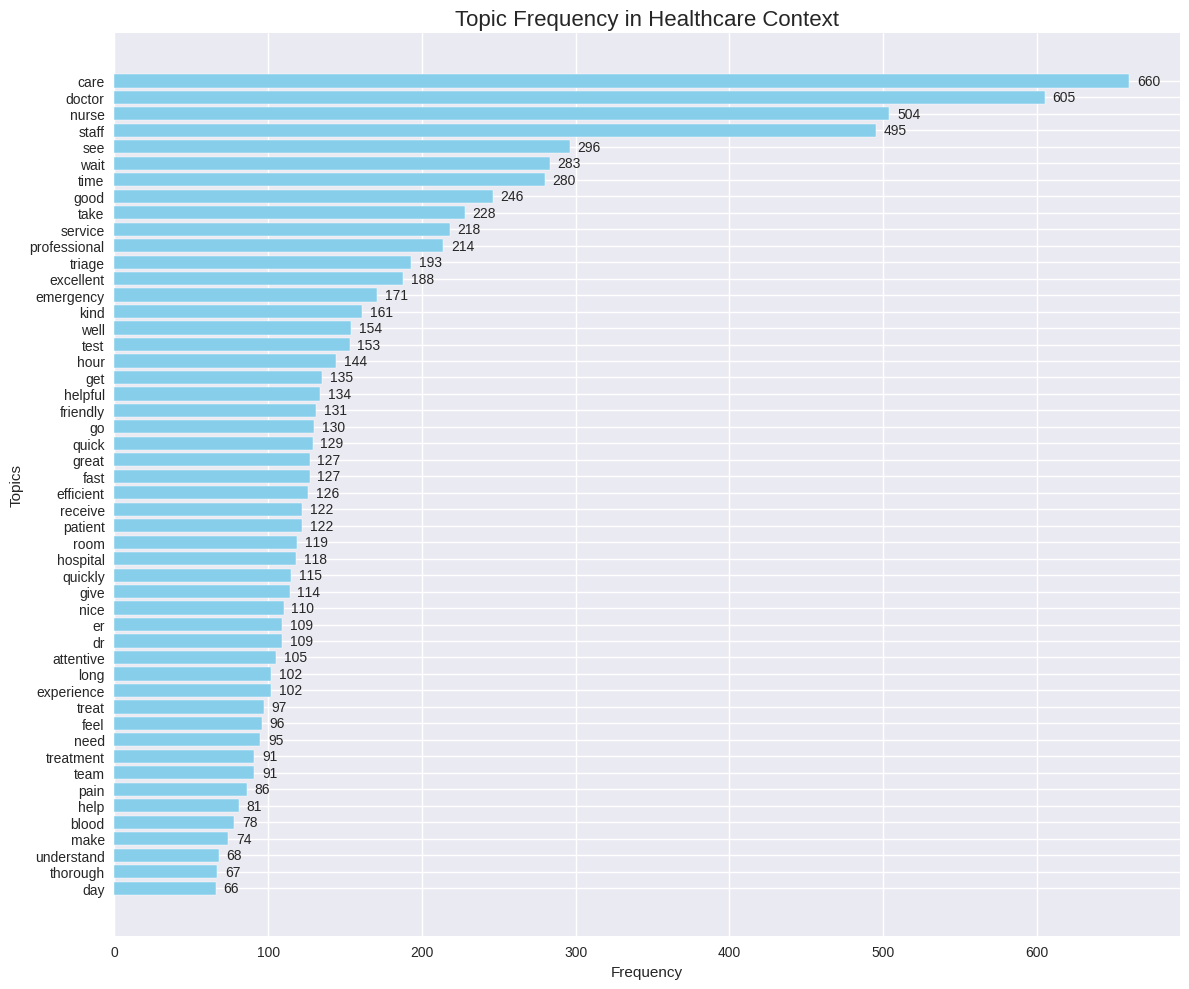

In [73]:
# Set plot style
plt.style.use('seaborn-v0_8')

# Create horizontal bar chart
plt.figure(figsize=(12, 10))
plt.barh(topic_draw['term'], topic_draw['frequency'], color='skyblue')
plt.xlabel('Frequency')
plt.ylabel('Topics')
plt.title('Topic Frequency in Healthcare Context', fontsize=16)
# Add frequency labels to bars
for index, value in enumerate(topic_draw["frequency"]):
    plt.text(value + 5, index, str(value), va="center")
plt.tight_layout()
plt.show()

# Topic Cloud

In [74]:
def get_cloud_df(ldaTopicsDf, vectorVocabulary): # inputs: lda_topics_df, vocab
    '''Prepare df to plot word cloud'''
    # explode array terms of each topic to row
    explodeTermIndices = ldaTopicsDf.select(ldaTopicsDf.topic, explode(ldaTopicsDf.termIndices)).withColumnRenamed("col","termIndices")
    explodeTerm = explodeTermIndices.rdd.map(lambda x: Row(topic=x['topic'], term=vectorVocabulary[x['termIndices']])) #term=Row(vectorVocabulary[x['termIndices']])
    explodeTerm = explodeTerm.toDF().withColumn("id", monotonically_increasing_id())

    explodeTermWeights = ldaTopicsDf.select(explode(ldaTopicsDf.termWeights)).withColumnRenamed("col","termWeights")
    explodeTermWeights = explodeTermWeights.withColumn("id", monotonically_increasing_id())

    cloudDf = explodeTerm.join(explodeTermWeights, 'id', 'outer').drop('id').orderBy('topic')
    return cloudDf

In [75]:
topic_cloud_df = get_cloud_df(lda_topics_df, vocab)
topic_cloud_df.show()

+-----+--------------+--------------------+
|topic|          term|         termWeights|
+-----+--------------+--------------------+
|    0|         great|0.007098458748872989|
|    0|      friendly|0.006454649083941774|
|    0|       service|0.006088706238386911|
|    0|         nurse|0.005387261216824297|
|    0|          fast|0.005383827900904022|
|    0|  professional|0.005280681657345807|
|    0|        triage|0.004191472663443676|
|    0|          nice|0.004012761679170589|
|    0|      be_great|0.003980294594033097|
|    0|     competent|0.003806615381935...|
|    1|          take|0.008929890661810186|
|    1|           get|0.007775982177478696|
|    1|          care|0.007577718633752416|
|    1|          test|0.005608061287120692|
|    1|     attentive|0.005526038469829119|
|    1|     excellent|0.004680060355704096|
|    1|          need|0.004574240836037592|
|    1|          feel|0.004565129739146827|
|    1|        listen|0.004325098699410877|
|    1|excellent_care|0.00378616

In [76]:
def plot_cloud_by_topic(cloudDf, n_topics):
    '''Plot word cloud of top N words in each topic'''
    cloud_df = cloudDf.toPandas()
    cloud = WordCloud(background_color='white',
                      width=2500,
                      height=1800,
                      max_words=10,
                      colormap='tab10',
                      color_func=lambda *args, **kwargs: cols[i],
                      prefer_horizontal=1.0)

    fig, axes = plt.subplots(2, int(n_topics/2), figsize=(n_topics,6), sharex=True, sharey=True)
    for i, ax in enumerate(axes.flatten()):
        fig.add_subplot(ax)
        cloud_df_sub = cloud_df.loc[cloud_df.topic == i]
        topic_words = dict(zip(cloud_df_sub.term, cloud_df_sub.termWeights))
        cloud.generate_from_frequencies(topic_words, max_font_size=500)
        plt.gca().imshow(cloud)
        plt.gca().set_title('Topic ' + str(i), fontdict=dict(size=16))
        plt.gca().axis('off')

    plt.subplots_adjust(wspace=0, hspace=0)
    plt.axis('off')
    plt.margins(x=0, y=0)
    plt.tight_layout()
    plt.show()

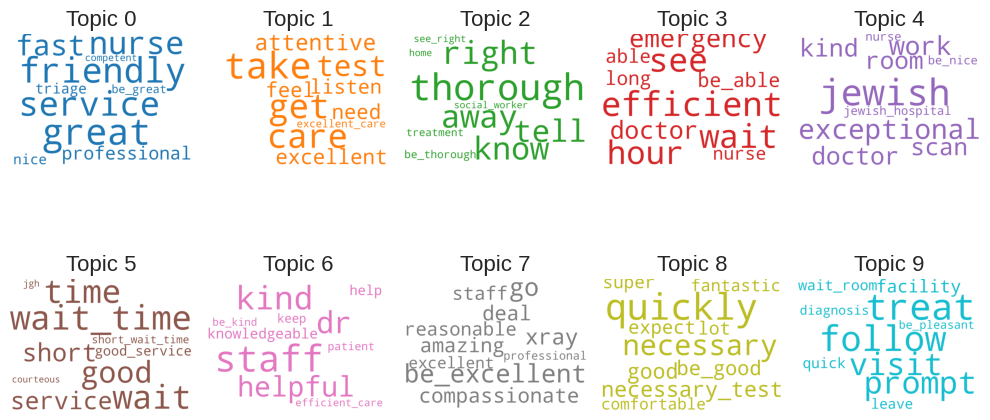

In [77]:
plot_cloud_by_topic(topic_cloud_df, n_topics=10)